# MF34 Multigroup Collapse: Fe-56 (JEFF-4.0)

This notebook applies the MF34-to-multigroup grouping to the JEFF-4.0 Fe-56 evaluation
using the SCALE 56-group energy structure. It produces two comparison figures:

1. **Grouped vs. original** first Legendre coefficient ($a_1$) with ±1σ uncertainty bands
2. **Uncertainty comparison** for $a_1$: ENDF vs MG vs NJOY
3. **Legendre coefficient comparison**: kika MG vs NJOY grouped $a_1$ values

In [1]:
import numpy as np
from kika.endf.read_endf import read_endf
from kika.cov.multigroup import MF34_to_MG
from kika.cov import MF34CovMat
from kika.energy_grids import SCALE56
from kika.plotting import PlotBuilder, PlotData

# --- Paths (edit these) ---
ENDF_PATH = '/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt'
NJOY_GENDF_PATH = '/share_snc/snc/JuanMonleon/COV/mf34_processing/26056_mf34_02.gendf'
# NJOY_GENDF_PATH = r'E:\OneDrive\Share\Juan\26056_mf34_02.gendf'
SAVE_DIR = '/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33'

# --- Load ENDF ---
endf = read_endf(ENDF_PATH)
print(f'MF4  MT reactions: {list(endf.mf[4].mt.keys())}')
print(f'MF34 MT reactions: {list(endf.mf[34].mt.keys())}')

# --- Load NJOY (optional) ---
njoy_cov = None
if NJOY_GENDF_PATH is not None:
    njoy_cov = MF34CovMat.from_covfil(NJOY_GENDF_PATH)
    njoy_cov = njoy_cov.remap_mt(251, 2)
    print(f'NJOY loaded: {njoy_cov.num_matrices} matrices')
else:
    print('NJOY GENDF path not set — skipping NJOY comparison')

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


MF4  MT reactions: [2, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818]
MF34 MT reactions: [2]
NJOY loaded: 1 matrices


In [2]:
# Extract covariance objects and determine isotope ZAID
mf4_mt = endf.mf[4].mt[2]
mf34_cov = endf.mf[34].mt[2].to_ang_covmat(mf4_data=endf.mf[4])
zaid = mf34_cov.isotopes[0]
print(f'Isotope ZAID: {zaid}')
print(f'Available Legendre orders: {sorted(set(mf34_cov.l_rows))}')

# Check if ENDF-path Legendre coefficients were populated
if mf34_cov.legendre_coefficients:
    print(f'ENDF Legendre coefficients stored for keys: {list(mf34_cov.legendre_coefficients.keys())}')
else:
    print('No ENDF Legendre coefficients populated (mf4_data not available)')

# Check NJOY Legendre coefficients
if njoy_cov is not None and njoy_cov.legendre_coefficients:
    print(f'NJOY Legendre coefficients stored for keys: {list(njoy_cov.legendre_coefficients.keys())}')

# Multigroup collapse using SCALE 56-group structure
SCALE56_eV = [e * 1e6 for e in SCALE56]

mg_cov = MF34_to_MG(
    endf_object=endf,
    energy_grid=SCALE56_eV,
    weighting_function='lethargy',
    isotope=zaid,
    mt=2
)
print(mg_cov)

Isotope ZAID: 26056
Available Legendre orders: [1, 2, 3, 4, 5, 6]
ENDF Legendre coefficients stored for keys: [(26056, 2, 1), (26056, 2, 2), (26056, 2, 3), (26056, 2, 4), (26056, 2, 5), (26056, 2, 6)]
NJOY Legendre coefficients stored for keys: [(26056, 2, 1)]
Multigroup MF34 Angular Covariance Matrix Data:
- 21 matrices
- 56 energy groups
- 1 unique isotopes
- 1 unique reaction types
- 6 unique Legendre indices
- Weighting: lethargy
- Normalization: mf34_cell


## Figure 1: Grouped vs. original $a_1$ with ±1σ bands

Uses `to_plot_data()` on `MF34CovMat` (ENDF), `MGMF34CovMat` (multigroup), and
NJOY's grouped Legendre coefficients (now stored in `MF34CovMat.legendre_coefficients`).

NJOY grouped a_1: 56 groups, first value = 0.01202


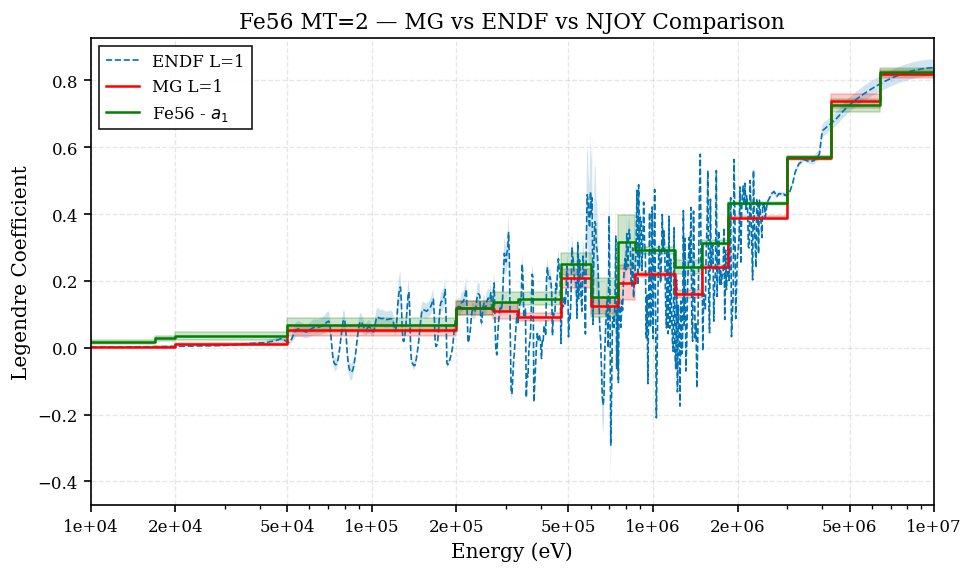

In [3]:
ENERGY_RANGE = (1e4, 1e7)

# ENDF dense curve + uncertainty from to_plot_data()
endf_data = mf4_mt.to_dense_plot_data(
    order=1, energy_range=ENERGY_RANGE,
    label="ENDF L=1", linestyle="--", linewidth=1,
)
_, endf_unc = mf34_cov.to_plot_data(nuclide=zaid, mt=2, order=1, sigma=1.0)

# MG step data + uncertainty from to_plot_data()
mg_data, mg_unc = mg_cov.to_plot_data(
    nuclide=zaid, mt=2, order=1, sigma=1.0,
    label="MG L=1", color="red", linewidth=1.5,
)

# Build figure
builder = (
    PlotBuilder(figsize=(12, 7), dpi=300)
    .add_data(endf_data, uncertainty=endf_unc)
    .add_data(mg_data, uncertainty=mg_unc)
)

# Add NJOY grouped Legendre coefficients (now available via legendre_coefficients)
if njoy_cov is not None:
    njoy_coeff, njoy_unc = njoy_cov.to_plot_data(
        nuclide=zaid, mt=2, order=1, sigma=1.0,
        label="NJOY L=1", color="green", linestyle="-", linewidth=1.5,
    )
    if njoy_coeff is not None:
        builder.add_data(njoy_coeff, uncertainty=njoy_unc)
        print(f'NJOY grouped a_1: {njoy_coeff.y.shape[0]-1} groups, first value = {njoy_coeff.y[0]:.5f}')
    else:
        print('NJOY legendre_coefficients not available for plotting')

fig1 = (
    builder
    .set_scales(log_x=True)
    .set_limits(x_lim=ENERGY_RANGE)
    .set_labels(
        x_label="Energy (eV)",
        y_label="Legendre Coefficient",
        title="Fe56 MT=2 — MG vs ENDF vs NJOY Comparison",
    )
    .set_legend(loc="best")
    .build()
)
fig1.savefig(f'{SAVE_DIR}/fe56_mg_vs_endf_a1.png', dpi=300, bbox_inches='tight')

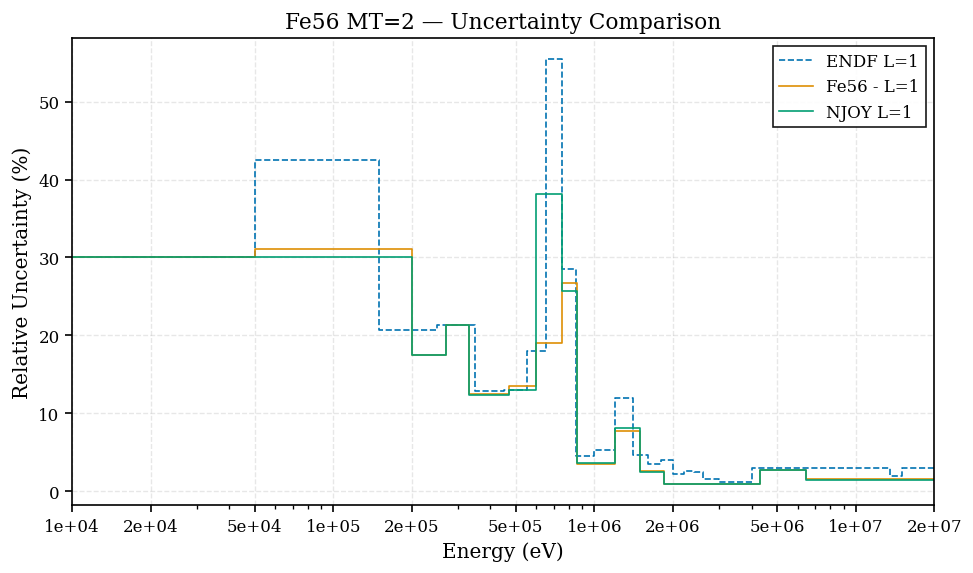

In [4]:
ENERGY_RANGE_UNC = (1e4, 2e7)

# All three sources use to_plot_data() — PlotBuilder renders as step lines
_, endf_unc = mf34_cov.to_plot_data(
    nuclide=zaid, mt=2, order=1, sigma=1.0,
    label="ENDF L=1", linestyle="--",
)
_, mg_unc = mg_cov.to_plot_data(
    nuclide=zaid, mt=2, order=1, sigma=1.0,
    label="MG L=1", color="red",
)

builder = PlotBuilder(figsize=(12, 7), dpi=300)
builder.add_data(endf_unc)
builder.add_data(mg_unc)

# NJOY (optional third trace)
if njoy_cov is not None:
    _, njoy_unc = njoy_cov.to_plot_data(
        nuclide=zaid, mt=2, order=1, sigma=1.0,
        label="NJOY L=1", linestyle="-",
    )
    if njoy_unc is not None:
        builder.add_data(njoy_unc)

fig2 = (
    builder
    .set_scales(log_x=True)
    .set_limits(x_lim=ENERGY_RANGE_UNC)
    .set_labels(
        x_label="Energy (eV)",
        y_label="Relative Uncertainty (%)",
        title="Fe56 MT=2 — Uncertainty Comparison",
    )
    .set_legend(loc="best")
    .build()
)
fig2.savefig(f'{SAVE_DIR}/fe56_mg_vs_endf_unc_a1.png', dpi=300, bbox_inches='tight')

## Figure 3: kika vs NJOY grouped Legendre coefficients

Direct comparison of the multigroup-averaged $a_1$ values from kika's `MF34_to_MG`
collapse versus the NJOY-processed grouped coefficients read from the GENDF file
(stored in `MF34CovMat.legendre_coefficients` via the MF3 sections of the covfil).

/tmp/ipykernel_3664/1579489909.py:47: UserWarning: The figure layout has changed to tight
  fig3.tight_layout()


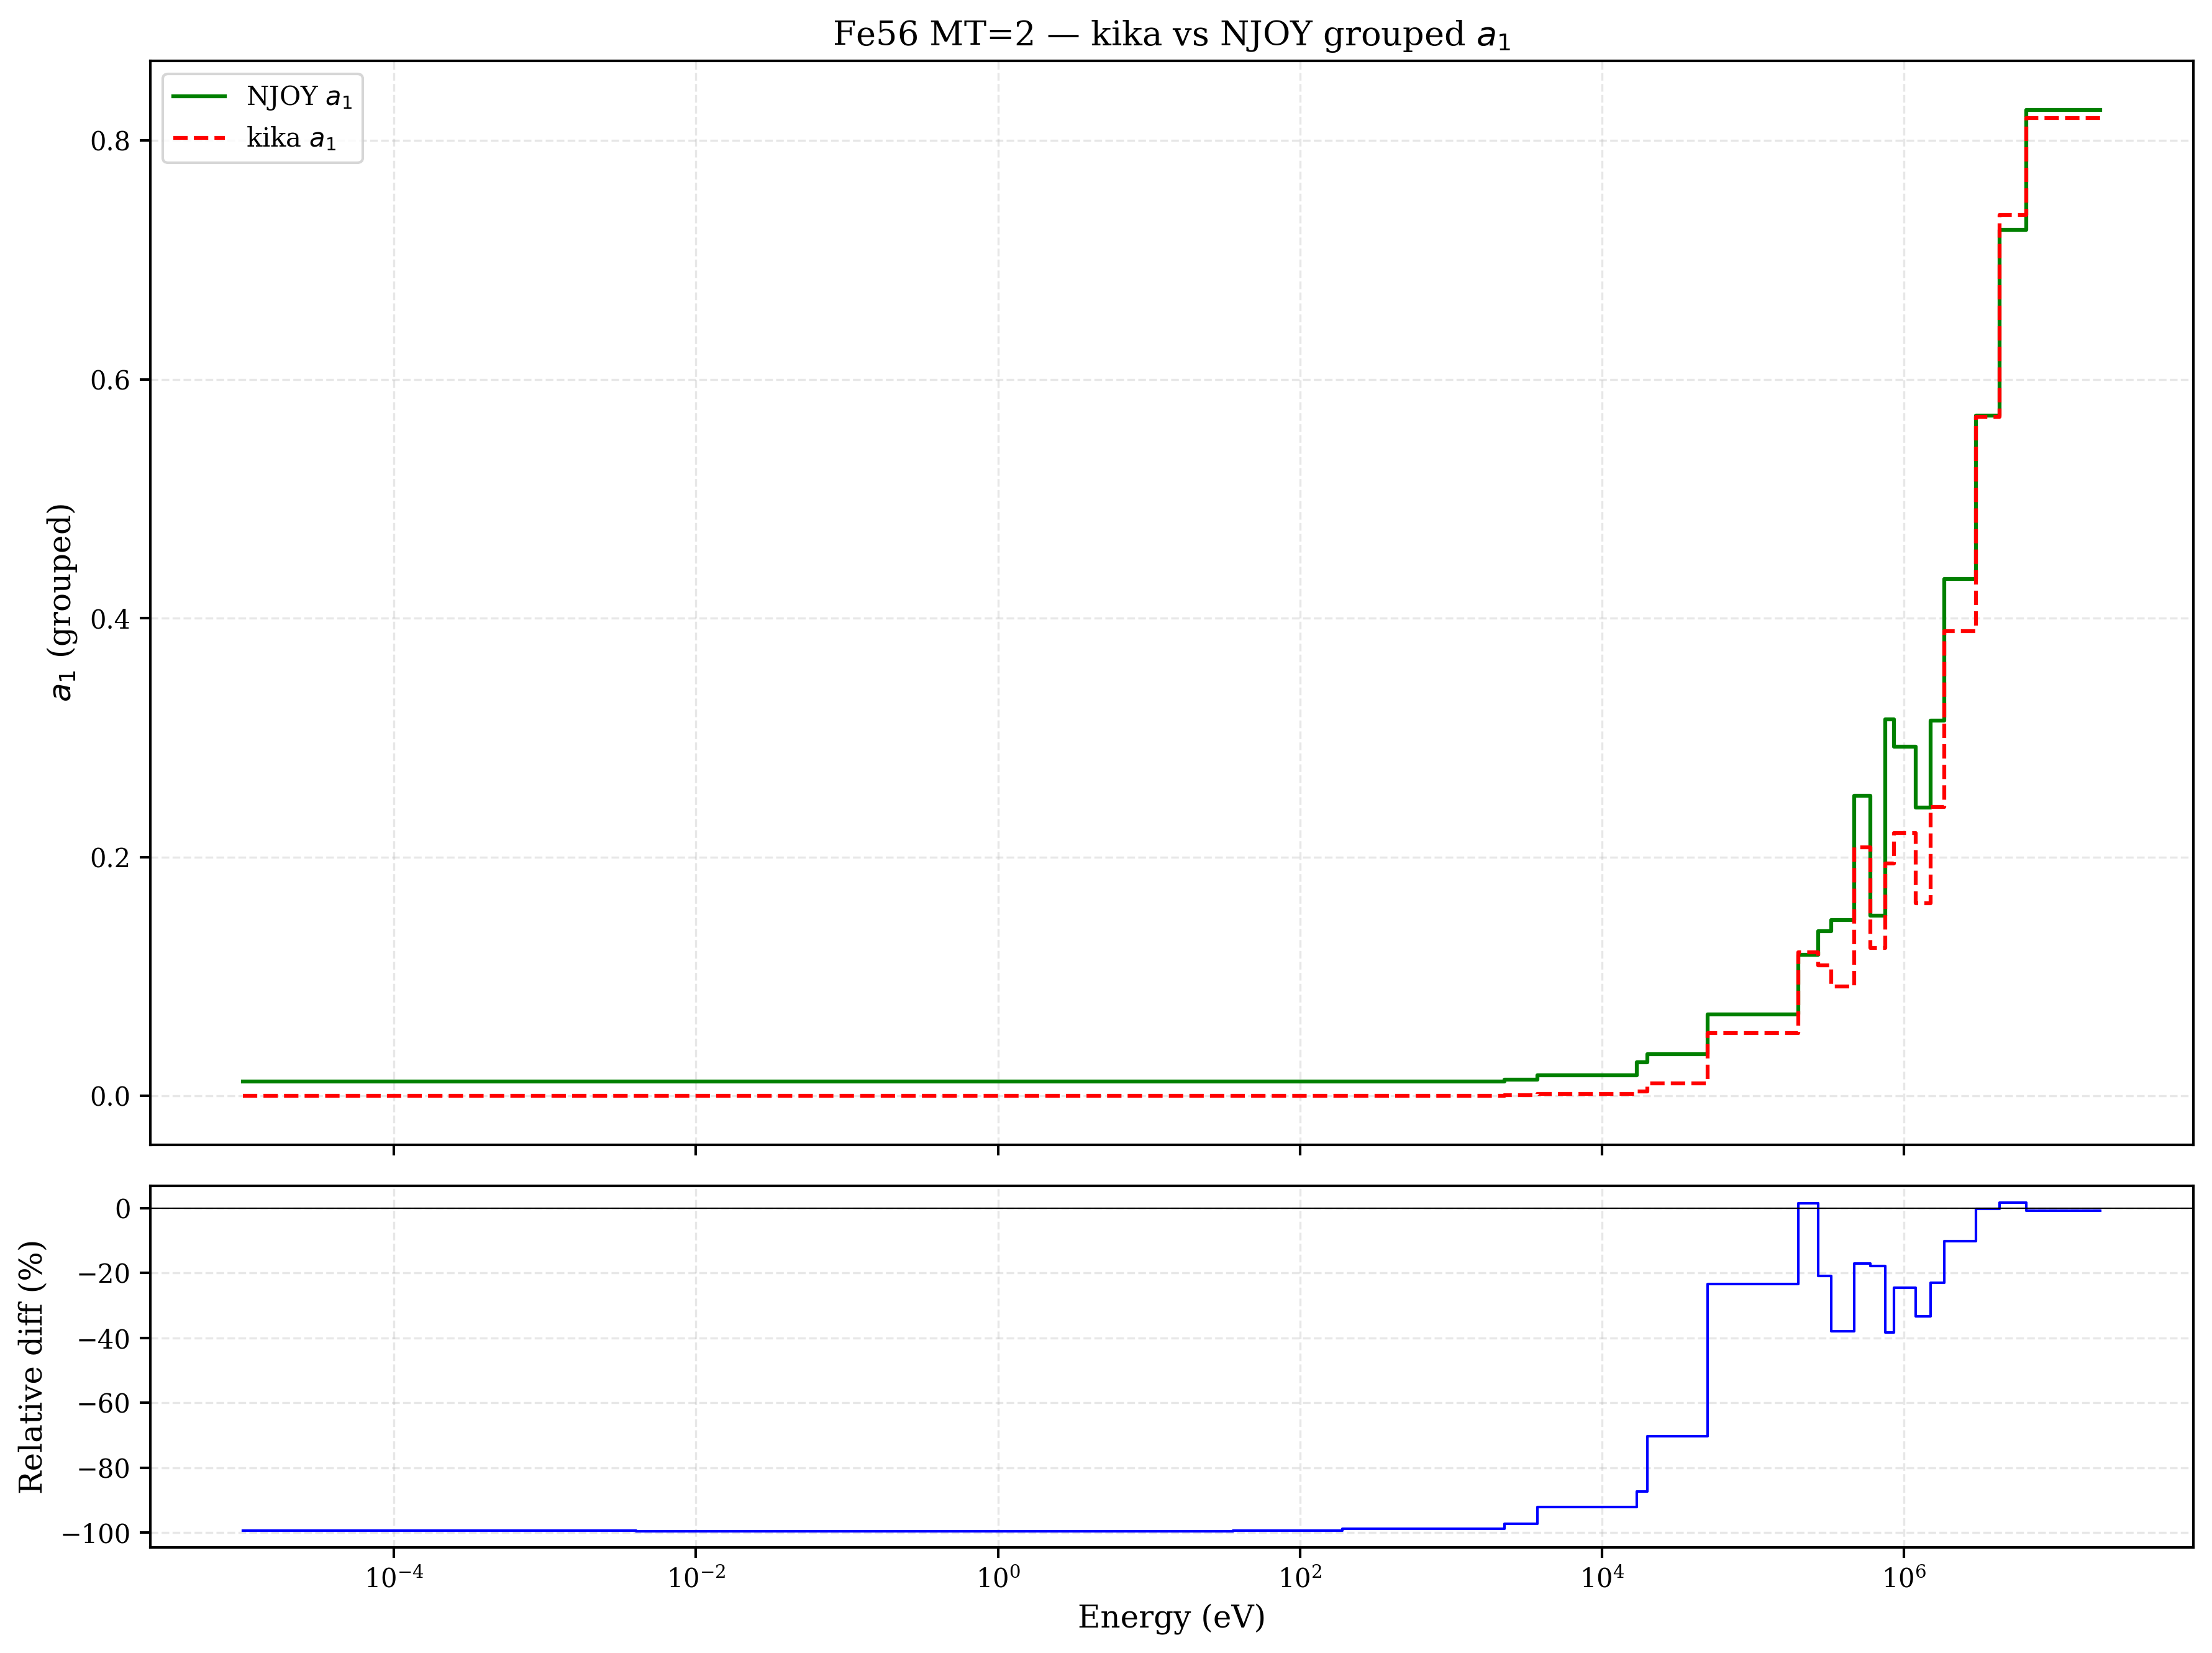

NJOY a_1 range: [0.012022, 0.825459]
kika a_1 range: [0.000059, 0.818932]


In [5]:
import matplotlib.pyplot as plt

if njoy_cov is not None and (zaid, 2, 1) in njoy_cov.legendre_coefficients:
    njoy_a1 = njoy_cov.legendre_coefficients[(zaid, 2, 1)]
    # NJOY energy grid: same for all matrices (the MG grid from the covfil)
    njoy_grid = np.array(njoy_cov.energy_grids[0])
    njoy_centers = np.sqrt(njoy_grid[:-1] * njoy_grid[1:])

    # kika MG a_1 from the MGMF34CovMat
    kika_a1 = mg_cov.legendre_coefficients[(zaid, 2, 1)]
    kika_grid = np.array(mg_cov.energy_grid)
    kika_centers = np.sqrt(kika_grid[:-1] * kika_grid[1:])

    fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), dpi=300, sharex=True,
                                     gridspec_kw={'height_ratios': [3, 1]})

    # Top: absolute values
    ax1.step(njoy_grid, np.append(njoy_a1, njoy_a1[-1]),
             where='post', label='NJOY $a_1$', color='green', linewidth=1.5)
    ax1.step(kika_grid, np.append(kika_a1, kika_a1[-1]),
             where='post', label='kika $a_1$', color='red', linewidth=1.5, linestyle='--')
    ax1.set_xscale('log')
    ax1.set_ylabel('$a_1$ (grouped)')
    ax1.set_title('Fe56 MT=2 — kika vs NJOY grouped $a_1$')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # Bottom: relative difference (%) where NJOY is reference
    # Need to interpolate kika onto NJOY grid if grids differ
    if len(njoy_a1) == len(kika_a1) and np.allclose(njoy_grid, kika_grid):
        # Same grid — direct comparison
        with np.errstate(divide='ignore', invalid='ignore'):
            rel_diff = np.where(np.abs(njoy_a1) > 1e-15,
                                (kika_a1 - njoy_a1) / njoy_a1 * 100.0,
                                0.0)
        ax2.step(njoy_grid, np.append(rel_diff, rel_diff[-1]),
                 where='post', color='blue', linewidth=1.0)
        ax2.set_ylabel('Relative diff (%)')
        ax2.axhline(0, color='k', linewidth=0.5)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, f'Different grids: NJOY={len(njoy_a1)} vs kika={len(kika_a1)} groups',
                 ha='center', va='center', transform=ax2.transAxes)

    ax2.set_xscale('log')
    ax2.set_xlabel('Energy (eV)')
    fig3.tight_layout()
    fig3.savefig(f'{SAVE_DIR}/fe56_kika_vs_njoy_a1.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'NJOY a_1 range: [{njoy_a1.min():.6f}, {njoy_a1.max():.6f}]')
    print(f'kika a_1 range: [{kika_a1.min():.6f}, {kika_a1.max():.6f}]')
else:
    print('NJOY grouped Legendre coefficient data not available for comparison')